In [ ]:
! pip install qiskit
! pip install qiskit-aer
! pip install qiskit-algorithms
! pip install plotly
! pip install pandas
! pip install dwave-tabu
! pip install pennylane
! pip install noisyopt

import warnings
#warnings.filterwarnings("ignore")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 75.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 87.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 113.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 99.

# Training »Applications of Quantum Computing«

Welcome at Fraunhofer IKS! This notebook is your companion for our one-day training »Applications of Quantum Computing« and will let you explore this exciting technology and get a feel for possible applications and challenges.

# Exploration: Quantum Computing and Probabilities

Quantum Computing is a technology that inherently gives you probabilistic results. To get a feel on what quantum circuits do and how they work, you can use a visual tool like the IBM Composer: https://quantum-computing.ibm.com/composer/files/new?initial=N4IgdghgtgpiBcICSBpAygfQIoGEAqAThAJZikDmIANCAI4QDOUCIA8gAoCiAclgIJoAsgAIATADoADAG4AOmTABjADYBXACYxhsujGXEARgEZxpRTrlh5tAjHLDaAbSMBdS4tv3Fzt-OohNBg9iAAcAF2IAezAWEABfIA

Feel free to play around with the quantum circuit and get familiar with the displays below (the probabilities, Q-sphere (which is similar to the Bloch sphere but for multiple qubits), and statevector). You can also follow this protocol:

1. Start with one qubit. A gate that almost every circuit needs is called the Hadamard gate (H) - it puts a single qubit from a pure $|0⟩$ state in a uniform superposition. What happens if you apply multiple Hadamard gates?
2. Next, experiment with the phase gate (P). What does it do when applied to the $|0\rangle$ state and a uniform superposition? How do the output probabilities change?
3. Now try to sandwich a phase gate between two Hadamards. Despite the phase gate alone not changing any probabilities, try varying its angle between the two Hadamards - what happens, is interference.

Next, let's add another qubit. Now, the histogram at the bottom will change to show you the four basis states $|00\rangle$, $|01\rangle$, $|10\rangle$ and $|11\rangle$ with their probabilities.

1. First, let's create an entangled state. All you need is a CNOT gate and a Hadamard gate. Have a look at the phase disk. If it shows a black circle within the disk - congrats, you have an entangled state. If its radius is half of the radius of the disk, it is even maximally entangled. Try out how to produce various different entangled states.

## Measurements

Here, we can see the state of the qubits at all times. On a real quantum computer we can access the states only via measurements. A measuremeent causes the qubit to 'collaps' to a classical state. For one qubit this is either 0 or 1. (What is it for two qubits?) This means in each single measurement we only get one of these two possibilities, but this gives us limited information on the state of the qubit before the measurement. To get an approximation what the state has been, we need to repeat the circuit and the measurement several times. The number of repetitions is also called *shots*. From these several measurements we get the probability for measuring a classical state.

1. Have a new circuit with a single qubit. Add a measurement. See how the phase disk on the very right changes.
2. The lower left probability diagram now shows the fraction of measurements with a certain outcome of 1024 measurements in total. See how it changes in comparison to the ideal probabilities without a measurement operator.
2. See how the probabilities correspond to the state of a qubit. If the qubit is in state $|0\rangle$ or $|1\rangle$ before the measurement, what probabilities do you get? What if you add a gate before the measurement to put it in equal superposition?
3. Produce an entangled state of two qubits. Another way to see whether a state is entangled or not, you can insert a "Measure" operation on one qubit and pay attention to the phase disks all the way to the right. If inserting the Measure operation also changes the disk of the qubit that wasn't measured, you have indeed an entangled state.

## Phase kick

Next, let's build a simple phase estimation algorithm - the phase of an operator isn't directly accessible since it doesn't influence measurement probabilities. We first do something very common in quantum algorithms: We divide our qubits into different registers, one "helper" register that we use to measure the phase that an operator applies to the second "working" register. In our case, both registers consist of one qubit. Let's build the circuit:

1. Choose some angle (e.g., $\pi/4$), and apply a controlled phase operator of that angle to the second qubit (our working register), controlled by the first (helping register). So far, the circuit does nothing (why?).
2. To estimate the phase the phase gate applies, the working register needs to start in the eigenstate $|1\rangle\$ this phase is applied to. Then, to make the controlled operation actually be applied, the helper register needs to start in a uniform superposition. Apply appropriate gates to do both of those things (there's one single-qubit gate at the beginning of the circuit now). (You can check the effect of each gate by inserting phase disks. They don't do anything but are just a visualization tool.)
3. Now, the magic happens: To convert the phase information on the whole state into probability information, apply a Hadamard gate to the helper qubit. Modify the phase of the phase gate to see how the probabilities change if you measure only the first qubit.

![](https://drive.google.com/uc?id=1neZ1XlT2TqxcQCBw_wc9B8rpkaQesDqn)

This kind of "trick" is very useful: You now managed to determine a property of an operator acting on the working register without ever needing to measure that register! In other words, you won't destroy superposition and can continue to use the working register - only the helper register is measured.

## Parametrized circuits

As you have seen with the controlled phase gate, there are gates that have a variable parameter. These can be used to build parametized quantum circuits that are used in variational hybrid quantum-classical algorithms.

Often they use rotation gates, that is RX, RY, and RZ. In the Bloch sphere picture they correspond to rotations around the x-, y- and z-axis by the specified angle (0 to 2$\pi$). Play around a bit to get some feel on it.

![Bloch Sphere](https://lh3.googleusercontent.com/u/0/drive-viewer/AK7aPaCJFn3AmDK3anb95xFpC-03R2wgjLuTEMOoBr1Vars6L_Xz2cUC3OWNNRQDnRrk1KzzEhg-mRr4H0t63g7KBdRwdz18=w2560-h1287)

<!---
![](https://drive.google.com/uc?id=1ekiv2AxWhvgImqDkDR4UII0fawx5hgD-)


<div>
<img src=https://lh3.googleusercontent.com/u/0/drive-viewer/AK7aPaCJFn3AmDK3anb95xFpC-03R2wgjLuTEMOoBr1Vars6L_Xz2cUC3OWNNRQDnRrk1KzzEhg-mRr4H0t63g7KBdRwdz18=w2560-h1287 width="180">
</div>

<div>
<img src=https://drive.google.com/uc?id=1ekiv2AxWhvgImqDkDR4UII0fawx5hgD- width="180">
</div>
-->

1. If you apply a RX gate with angle $\pi$, what would you expect the state to be? To what other gate does this correspond? What do you expect for angle $\pi/2$?
2. What happens when you apply an RZ gate instead? What if you apply a Hadamard gate first?
3. With rotation gates alone you cannot produce entanglement. Add an additional gate on two qubits to change this. Now there are more states that the circuit can represent, without adding additional parameters.

## Measurement of observables

We have seen before that a measurement causes the state to collaps to 0 or 1. For the case of a single qubit, this corresponds in the Bloch sphere picture to a projection of the statevector to the z-axis. This is indicated by the small 'z' in the icon for the measurement operator. In theory, you can project to any other axis as well.
1. Build some one-qubit circuit. Add as last gate an RX with angle $\pi/2$. The measurement then corresponds to a projection onto the x-axis of the Bloch sphere. What is now the expected outcome of the measurement if the circuit without the last gate prepares state $|0\rangle$ or $|1\rangle$ or a state in superposition?
This axis of projection represents a so-called *observable* and one 'measures an observable'.

# Tutorial: Quantum Simulation with the Variational Quantum Eigensolver

## Describing a system -  the Hamiltonian and the ground state

The energy of a physical system can be represented by a so-called *Hamiltonian*.

Take for example a ball in a ditch. Depending on its position x and momentum p it will have a certain kinetic energy - the energy from its movement - and a potential energy - the energy that it takes to move the ball uphill to its position. The sum of these two terms - the Hamiltonian - gives us the energy of the ball at each position. So, the Hamiltonian is a function $H(x,p)$ and the energy of a particular state with $x=x_0$ and $p=p_0$ is the number $H(x_0, p_0)$. We now want to find the state, i.e. the the position and momentum, of the ball with the lowest energy. We call this the *ground state* and this lowest energy the *ground state energy*. The ground state is also the most stable state a system can be in. For this example we know the ground state from experience: Lying at the bottom of the ditch without any movement. If one wanted to bring it from this state in another one, ie. move it for example uphill, one would need to bring energy into the system.

<!---
![ball](https://drive.google.com/uc?id=1ZDNwbrabgPkRqthYr-X7bBN8lf4VfJ8T)


<div>
  ![ball](https://drive.google.com/uc?id=1ZDNwbrabgPkRqthYr-X7bBN8lf4VfJ8T)
</div>

<div>
<img scr=https://drive.google.com/uc?id=1ZDNwbrabgPkRqthYr-X7bBN8lf4VfJ8T>
</div>

<img scr=https://drive.google.com/uc?id=1ZDNwbrabgPkRqthYr-X7bBN8lf4VfJ8T width="500"/>
-->

<div>
<img src=https://drive.google.com/uc?id=1ZDNwbrabgPkRqthYr-X7bBN8lf4VfJ8T width="500">
</div>


This concept of a Hamiltonian applies to both classical systems, like the ball, and quantum mechanical ones, like a molecule.

## VQE - the task
The task of the VQE is to find an approximate solution for the ground state energy of a system. Since we know that the ground state energy is the lowest possible, we know that if we pick some set of states of the system, the lowest energy of one of them is equal or higher than the ground state energy.

## The Variational Quantum Eigensolver

We call this set of states we pick an ansatz and implement it by a parametrized quantum circuit. Then we find the one with the lowest energy and thus get an upper bound on the ground state energy. The Hamiltonian itself is thereby represented by a sum of oberservables of the quantum state.

VQE implements the following strategy:

1. Inputs: Pick the setup: Hamiltonian (in a certain representation), an ansatz (= a relatively small quantum circuit depending on some parameters), initial values for the parameters that define the circuit, and a classical optimizer.
2. Execute the quantum circuit with the given parameters to produce a trial state and compute its energy.
3. Pass the obtained values to a classical optimization routine with the task to minimize the energy.
4. The classical optimization routine produces a new set of parameters - restart from 2 until it converges.

<!---
![image_vqe_cao](https://drive.google.com/uc?id=1Dr__DupHYFTae-h2ep3pwqBUnkzZoDG_){width=200}

![](https://drive.google.com/uc?id=1rci_Js3RBe8LfYGIE07H5_aj3PIgZFSu)
--->
<div>
<img src=https://drive.google.com/uc?id=1rci_Js3RBe8LfYGIE07H5_aj3PIgZFSu width="500">
</div>

## Hands-On: Solving Simulation Problems with VQE

Let's implement this algorithm to find the ground state energy of a simple molecule: the H$_2$!

<!---
![image_H2](https://drive.google.com/uc?id=1MVIHPWyJrIxthTDZqIKexn0DS1h-FYfD)
--->

<div>
<img src=https://drive.google.com/uc?id=1MVIHPWyJrIxthTDZqIKexn0DS1h-FYfD width="160">
</div>


We start by defining the Hamiltonian:


In [ ]:
from pennylane import qchem
from pennylane import numpy as np

# define the molecule
symbols = ["H", "H"]
coordinates = np.array([ 0.0, 0.0, -0.70076, 0.0, 0.0, 0.70076])

# get the hamiltonian
ham, num_qubits = qchem.molecular_hamiltonian(symbols, coordinates)

print(f"For this molecule {num_qubits} qubits are required.")
#print(f"The Hamiltonian has {len(ham.coeffs)} terms:")
#print(ham)

For this molecule 4 qubits are required.


Then we define the quantum circuit that gives us the set of states among which we search for the one with minimal energy:

In [ ]:
import pennylane as qml

# the H2 has 2 electrons
electrons=2
#define the position the electrons start out
ref_state = qchem.hf_state(electrons, num_qubits)
#define the possibilities of changing the positions of the electrons
singles, doubles = qchem.excitations(electrons, num_qubits) # Generate single and double excitations
s_wires, d_wires = qchem.excitations_to_wires(singles, doubles) # Map excitations to the wires the UCCSD circuit will act on

#define the quantum circuit
def VQE_circuit(params):
    qml.UCCSD(params, wires=[i for i in range(num_qubits)], s_wires=s_wires,d_wires=d_wires,init_state=ref_state)
    return qml.expval(ham)

# def VQE_circuit(params):
#   # ansatz
#   #qml.BasisState(np.array([0,0,1,1]), wires=range(num_qubits))
#   qml.RX(np.pi, wires=0)
#   qml.RX(np.pi, wires=1)
#   for i in range(num_qubits):
#     qml.RY(params[i], wires=i)
#   qml.CNOT(wires=[0,1])
#   qml.CNOT(wires=[1,2])
#   qml.CNOT(wires=[2,3])
#   # measure Hamiltonian expectation value
#   return qml.expval(ham)

# print the circuit
dev= qml.device('default.qubit', wires=num_qubits)
circuit=qml.QNode(VQE_circuit, dev)
#print(qml.draw(circuit, expansion_strategy='device')([0,0,0]))

As classical optimizer we pick an algorithm called SPSA, that finds a minimum of a function by iteratively finding the approximate direction in which it goes 'downhill'. Then, we define the algorithm:

In [ ]:
import time
from noisyopt import minimizeSPSA


def run_vqe(ham, verbose=True):
    '''
    wrapper for run_vqe_optimization
    '''
    #ansatz
    electrons=2
    ref_state = qchem.hf_state(electrons, num_qubits)
    singles, doubles = qchem.excitations(electrons, num_qubits)
    s_wires, d_wires = qchem.excitations_to_wires(singles, doubles)
    def VQE_circuit(params):
        qml.UCCSD(params, wires=[i for i in range(num_qubits)], s_wires=s_wires,d_wires=d_wires,init_state=ref_state)
        return qml.expval(ham)

    # define pennylane device and cost function
    devicename='default.qubit'
    dev=qml.device(devicename, wires=num_qubits)
    cost = qml.QNode(VQE_circuit, dev)

    #define hyperparameters of the vqe
    num_params=3
    initial_parameters = np.array([-0.251383 ,  -0.27741414 , 2.32669295]) #np.random.normal(0, np.pi, num_params, requires_grad=True)

    num_iterations=30
    a_value=1.5 # hyperparameters for SPSA
    c_value=0.3 # hyperparameters for SPSA

    parameters, energies, run_time = \
        run_vqe_optimization(initial_parameters, num_iterations, a_value, c_value, cost, verbose)
            # for formatting you can use \ in python to break a line in two that would otherwise be too long

    #change format of energies from list of tensors to list of floats
    energies = [float(e) for e in energies]
    return parameters, energies, run_time

def run_vqe_optimization(initial_parameters, num_iterations, a_value, c_value, cost, verbose):
    '''
    run the VQE
    parameter:
        initial_parameters: parameters to start the optimization from (numpy array)
        num_iterations: number of optimization iterations (int)
        a_value: for SPSA (float)
        c_value: for SPSA (float)
        cost: cost function for the optimization (qnode)
    returns:
        parameters: list of the parameters in each iteration
        energies: list of energies in each iteration
        run_time: time the execution took
    '''
    params = initial_parameters.copy()

    start_time = time.time()

    #for logging the results
    parameters=[]
    energies=[cost(params)]
    # log every step in the optimization; params_k are the parameters in the current iteration
    def callback_fn(params_k):
        parameters.append(params_k)
        energy=cost(params_k)
        energies.append(energy)
        if verbose: print('optimizing...',energy)

    # do the optimization
    res= minimizeSPSA(
        cost,
        x0 = params,
        niter= num_iterations,
        paired = False,
        a = a_value,
        c = c_value,
        callback=callback_fn
    )

    end_time = time.time()
    run_time = end_time - start_time

    return parameters, energies, run_time

Finally, run it and see how the energy is minimized step by step:

optimizing... -0.5145099860622893
optimizing... -0.5989171330456617
optimizing... -0.6818552193248681
optimizing... -0.6930754127899994
optimizing... -0.7386790280416128
optimizing... -0.7911239677983408
optimizing... -0.8176174062462924
optimizing... -0.8356990810927724
optimizing... -0.8457990922677598
optimizing... -0.8526949241036922
optimizing... -0.9664482391521417
optimizing... -1.0104204684459284
optimizing... -1.0562170989996293
optimizing... -1.0792129941652528
optimizing... -1.0899645434075438
optimizing... -1.106741798713438
optimizing... -1.1068235040102687
optimizing... -1.112460958999569
optimizing... -1.1125072393181148
optimizing... -1.112515461021363
optimizing... -1.1190833683980055
optimizing... -1.1192678445411315
optimizing... -1.1223783924512116
optimizing... -1.1240825725326329
optimizing... -1.1250263130374052
optimizing... -1.1255567287545203
optimizing... -1.1257364871136566
optimizing... -1.1257963406412457
optimizing... -1.1268268615387114
optimizing... -1.

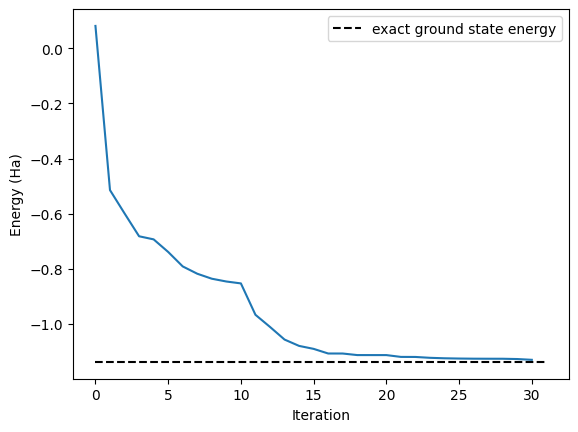

In [ ]:
#actually run it
parameters, energies, runtime= run_vqe(ham)

print(f'The optimization took {runtime} seconds.')

#plot results
import matplotlib.pyplot as plt
spectrum = qml.eigvals(ham)
plt.plot([i for i in range(len(energies))],energies)
plt.xlabel('Iteration')
plt.ylabel('Energy (Ha)')
plt.hlines(spectrum[0], 0, len(energies),
    linestyles='dashed', colors='black', label = 'exact ground state energy')
plt.legend()

### A chemically relevant quantity - the dissociation energy
Great, we can find the ground state energy of the H2 molecule!

Now, let's use this as a subroutine to calculate the dissociation energy of the molecule, ie. the energy that is needed to separate the two hydrogen atoms and make a reaction H2 -> H + H possible.

For this, we calculate the ground state energy as a function of the distance between the two hydrogen atoms:

VQE for interatomic distance 0.7 finished.
VQE for interatomic distance 1 finished.
VQE for interatomic distance 1.1 finished.
VQE for interatomic distance 1.2 finished.
VQE for interatomic distance 1.4 finished.
VQE for interatomic distance 1.5 finished.
VQE for interatomic distance 1.7 finished.
VQE for interatomic distance 2 finished.
VQE for interatomic distance 2.5 finished.
VQE for interatomic distance 3 finished.
VQE for interatomic distance 4 finished.
VQE for interatomic distance 5 finished.
VQE for interatomic distance 6 finished.
The calculated dissociation energy is 0.201 Ha.


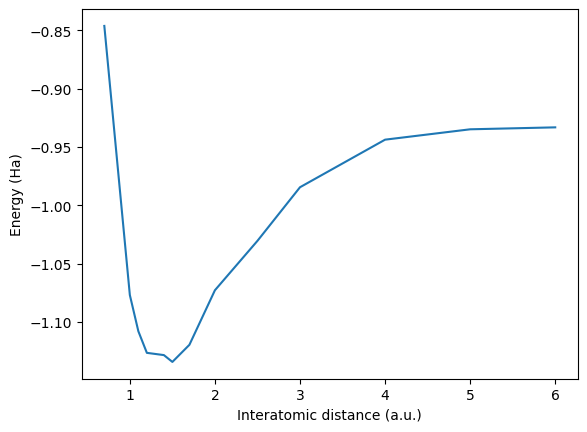

In [ ]:
def calculate_energy_surface(molecule, interatomic_distances):

  Final_energies=[]
  Energies=[]
  Exact_energies=[]

  for d in interatomic_distances:
    ham, num_qubits = qchem.molecular_hamiltonian(molecule, np.array([ 0.0, 0.0, - d/2, 0.0, 0.0, d/2]))
    parameters, energies, runtime = run_vqe(ham, verbose=False)
    print(f'VQE for interatomic distance {d} finished.')
    #exact_gs_energy = qml.eigvals(ham)[0]
    #Exact_energies.append(exact_gs_energy)
    Final_energies.append(energies[-1])
    Energies.append(energies)

  return Final_energies, Energies, Exact_energies

interatomic_distances = [0.7,1, 1.1, 1.2, 1.4, 1.5, 1.7, 2, 2.5, 3, 4, 5, 6]
Final_energies, Energies, Exact_energies = calculate_energy_surface(['H','H'], interatomic_distances)

plt.figure()
plt.plot(interatomic_distances, Final_energies)
plt.xlabel('Interatomic distance (a.u.)')
plt.ylabel('Energy (Ha)')

print('The calculated dissociation energy is %1.3f Ha.'% (Final_energies[-1]-min(Final_energies)))

We see that the energy for a distance of around 1.4 au , where the two atoms are bounded with eachother to a molecule, is smaller that for a distance of more than 6 au, where the two atoms act as separate instances. The difference between these two configurations is the dissociation energy and determines the energy needed to initiate the separation reaction - or, the other way round, the energy that is set free if two separate atoms are bound to each other.

# Tutorial: The Travelling Salesperson Problem with the Variational Quantum Eigensolver

## What's Different from Simulation?

When solving optimization problems like the TSP with VQE, the only additional step we need is the encoding. We translate the original problem into a Hamiltonian (or, equivalently, a quadratic unconstrained binary optimization (QUBO) problem) whose ground state we can then find with VQE.

The problem can be stated as follows:

Given a number of points, find the shortest route that connects all of them and returns to its starting point.

![Travelling Salesperson Problem](https://algorithms.discrete.ma.tum.de/graph-games/tsp-game/img/tour_107.png)

In fact, it turns out that a better representation than a list of coordinates is a distance matrix that lists the distance between the individual points - this allows easy modifications like replacing distances with travel time, fuel consumption etc. For example, the following code block generates an example TSP instance with its coordinate list and distance matrix.

In [ ]:
import numpy as np
import plotly.express as plt #plotly.express is the part of plotly for simple plotting

num_cities = 5
seed = 1245 #to get reproducible results, fixing the random seed is useful
max_coord = 100

np.random.seed(seed) #sets the seed
city_positions = max_coord*np.random.random((num_cities, 2))

distance_matrix = np.zeros((num_cities, num_cities))

for i in range(num_cities):
    for j in range(num_cities):
        distance_matrix[i,j] = np.linalg.norm(city_positions[i] - city_positions[j]) #norm is the length of a vector

print("City positions:")
print(city_positions)
print("Distance matrix:")
print(distance_matrix)
plt.scatter(x = city_positions.T[0], y = city_positions.T[1], text=list(range(num_cities)), width=800, height=800)

City positions:
[[33.38732121 87.08213358]
 [19.64650467  5.20682447]
 [90.7134397   6.68952129]
 [79.99857608 57.90385741]
 [40.69695511 52.64690933]]
Distance matrix:
[[ 0.         83.02033655 98.73832069 54.9907345  35.20249162]
 [83.02033655  0.         71.08240038 80.120845   51.90070438]
 [98.73832069 71.08240038  0.         52.32319301 67.92444513]
 [54.9907345  80.120845   52.32319301  0.         39.65164453]
 [35.20249162 51.90070438 67.92444513 39.65164453  0.        ]]


Now, encoding the TSP into an Ising model takes several steps:

1. Find a formulation as a discrete (integer) optimization problem.
2. Translate this formulation into a quadratic unconstrained binary optimization problem (QUBO) and that one into an Ising model.

We start with the first step. An easy way is to represent a route with its order of cities (starting the count from 0, a path would be (0,3,2,4,1) for instance. The set of possible choices for our TSP with 5 cities is therefore the set of all permutations of the sequence (0,1,2,3,4). Its objective function is easily computed - just add up the corresponding elements of the distance matrix (without forgetting to cycle back from the last city to the first in the end). Try out some paths!

In [ ]:
example_path = [0,3,2,4,1] # for num_cities=5

def path_length(path, distance_matrix):
    """takes a city ordering and returns the corresponding path length

    Input:
    path - a list of city labels containing each city once
    distance_matrix - a matrix containing the distance between the city pairs

    Output:
    out - the path length obtained by travelling to all cities in the order specified in path and then returning to the first one
    """
    path_copy = list(path)
    path_copy.append(path[0]) # make sure we return to the first city
    out = 0
    for city_1, city_2 in np.lib.stride_tricks.sliding_window_view(path_copy, 2): #sliding_window_view is a nice trick to go along a list while always taking adjacent elements
        out += distance_matrix[city_1, city_2] # complete here

    return out

print(path_length(example_path, distance_matrix))

310.15941357261977


In principle, we can already write a classical algorithm now that simply tries out all possible paths and selects the shortest one. Obviously, this is not very efficient and will only work for quite small problems, but it guarantees you the best solution.

In [ ]:
from itertools import permutations #now, you can use the function just as permutations(something) instead of itertools.permutations(something)
import math

def brute_force(distance_matrix):
    """computes the solution of a TSP instance with brute-force search

    Input:
    distance_matrix - a nxn symmetric matrix that specifies the distances between the n cities of the TSP instance

    Output:
    best_length - the length of the shortest path
    best_path - A list containing the order the cities should ideally be visited in
    """
    #do something here

    num_cities = len(distance_matrix)
    best_length = math.inf

    for current_path in permutations(list(range(num_cities))):
        current_length = path_length(current_path, distance_matrix)
        if current_length < best_length:
            best_length = current_length
            best_path = current_path

    return best_length, best_path

solution_length, solution_path = brute_force(distance_matrix)

print(f"The best path is visiting the cities in the order {solution_path} and has length {solution_length}") # formatting strings like this is a relatively new Python feature, but makes it a lot easier (in my opinion)


The best path is visiting the cities in the order (0, 3, 2, 1, 4) and has length 265.49952389750496


But now onto the second step: The binary formulation. There are multiple options, but without going into detail, we take a simple one called one-hot encoding. Each of the five numbers representing a path is encoded with five binary variables. We only allow one of these variables to be "on" (1) and require all others to be "off" (0). For example, a "3" will be translated to "00010" (the third bit is 1) and a "0" will be translated to "10000" (the zeroth bit is 1).

Since we have five numbers to encode with five binaries each, we need a total of 25 qubits. Now, we will also have to include constraints in our problems to ensure our solution is a valid path:

1. Each of the five integer variables need to be different, since something like "0, 1, 1, 3, 4" is not a valid path (city 1 is visited twice, and city 2 not at all).
2. The binary representations need to be valid one-hot encodings (only one bit for each variable can be "1" - for example, "10010" is not a valid one-hot state since it's neither "0" nor "3").

The way how we ensure these constraints are met is via penalties, additional terms that artifically lead to higher energy (and therefore a suboptimal state) if the constraints are violated. The final and relatively complicated cost function is then given by

$$
C (\{x_{ij}\}) = \sum_{k=0}^{n-1} \sum_{i,j=0}^{n-1} d_{ij} x_{i,k} x_{i, k+1} + P \left[\sum_{i=0}^{n-1} \left(1 - \sum_{j=0}^{n-1} x_{ij}\right)^2 +  \sum_{j=0}^{n-1} \left(1-\sum_{i=0}^{n-1} x_{ij}\right)^2 \right].
$$

For programming purposes, this can be represented by a 25x25 matrix, the QUBO matrix: Each element corresponds to one coefficient between two variables. This is what the following code block implements.


In [ ]:
from qiskit.quantum_info import SparsePauliOp

def tsp_to_qubo(distance_matrix, penalty_factor):
    """returns the generalized QUBO matrix for the TSP instance

    Parameters:
    distance_matrix     The distance matrix of the TSP instance.
    penalty_factor      the factor penalizing the constraints

    Returns:
    qubo_matrix         A 4D-matrix representing the QUBO problem
    """
    adjacency_matrix = np.array(distance_matrix)
    adjacency_matrix = (
        adjacency_matrix + adjacency_matrix.T
    ) / 2  # already include the scaling factor here
    num_nodes = np.shape(adjacency_matrix)[0]

    qubo_matrix = np.zeros((num_nodes,) * 4)

    for i, j, k, l in np.ndindex(*((num_nodes,) * 4)):
        if ((j - l) % num_nodes in [1, num_nodes - 1]) and (
            num_nodes * i + j < num_nodes * k + l
        ):
            qubo_matrix[i, j, k, l] = adjacency_matrix[i, k]

    offset = (
        2 * num_nodes * penalty_factor
    )  # each constraint gives an offset of penalty_factor

    for i in range(num_nodes):
        for j in range(num_nodes):
            qubo_matrix[i, j, i, j] -= 2 * penalty_factor
            for k in range(j + 1, num_nodes):
                qubo_matrix[j, i, k, i] += 2 * penalty_factor
                qubo_matrix[i, j, i, k] += 2 * penalty_factor

    return qubo_matrix

def get_qubo_offset(num_cities, penalty_factor):
    """computes the offset when passing from a TSP to the QUBO

    Inputs:
    num_cities - the number of cities of the TSP
    penalty_factor - the penalty factor chosen when formulating the QUBO

    Output:
    offset - the constant offset dropped in the QUBO formulation
    """
    offset = 2*num_cities*penalty_factor

    return offset

def get_pauli_string(num_qubits, z_qubits):
    """returns a Pauli string for num_qubits total and coupling the qubits in the z_qubits list"""
    charlist = ["I"]*num_qubits
    for qubit in z_qubits:
        charlist[qubit]="Z"
    return "".join(charlist)

def qubo_to_ising(qubo_matrix):
    """transforms a qubo tensor into an Ising operator. Should equally work with a qubo matrix"""
    qubo_matrix = np.array(qubo_matrix)
    num_cities = np.shape(qubo_matrix)[0]
    qubo_matrix = (qubo_matrix + qubo_matrix.T)/2 #make sure qubo matrix is symmetric (makes the computations easier)
    J = qubo_matrix/4

    for i in range(num_cities):
        for j in range(num_cities):
            J[i,j,i,j] = 0 # those terms are a constant offset anyways

    h = -np.sum(qubo_matrix, axis=(0,1))/2
    num_qubits = num_cities**2

    pauli_strings = []
    pauli_coeffs = []

    for i in range(num_cities):
        for j in range(num_cities):
            qubit_index = i*num_cities + j
            if h[i,j] != 0:
                pauli_strings.append(get_pauli_string(num_qubits, [qubit_index]))
                pauli_coeffs.append(h[i,j])

    for i in range(num_cities):
        for j in range(num_cities):
            for k in range(num_cities):
                for l in range(num_cities):
                    qubit_1 = i*num_cities + j
                    qubit_2 = k*num_cities + l

                    if J[i,j,k,l] != 0:
                        pauli_strings.append(get_pauli_string(num_qubits, [qubit_1, qubit_2]))
                        pauli_coeffs.append(J[i,j,k,l])

    H = SparsePauliOp(pauli_strings, pauli_coeffs)
    H = H.simplify()

    return H

def tsp_to_ising(distance_matrix, penalty_factor):
    """formulates a TSP directly into an Ising operator

    Inputs see in the tsp_to_qubo function.
    """
    qubo_matrix = tsp_to_qubo(distance_matrix, penalty_factor)
    return qubo_to_ising(qubo_matrix)

## Applying VQE

With the Ising model defined, all we need to do now is choose an ansatz and run the algorithm to try to solve our system. A lot of it is already implemented in Qiskit - additionally, we only need a few functions to build an ansatz and we're ready to go. To run simulations quickly, let's try it with a TSP with only four cities.

In [ ]:
import numpy as np
import math
from itertools import permutations
import qiskit
from qiskit.circuit import Parameter
from qiskit_algorithms.minimum_eigensolvers import VQE, SamplingVQE # the core VQE class
from qiskit.primitives import BackendEstimator, BackendSampler # wrapper that sets up the simulator so it can be used directly within VQE
from qiskit import Aer # module that provides us with simulators to execute the quantum circuits
import qiskit_algorithms.optimizers as opt # module with many optimizers that we can use directly


def random_positions(num_cities, seed=None, max_coord = 100):
    """creates a list of random positions"""#
    if seed is not None:
        np.random.seed(seed) #sets the seed
    city_positions = max_coord*np.random.random((num_cities, 2))
    return city_positions

def distance_matrix(city_positions):
    """creates the distance matrix of a list of positions"""
    num_cities = len(city_positions)
    out = np.zeros((num_cities, num_cities))

    for i in range(num_cities):
        for j in range(num_cities):
            out[i,j] = np.linalg.norm(city_positions[i] - city_positions[j])

    return out

def random_distance_matrix(num_cities, seed=None, max_coord = 100):
    """creates a random TSP distance matrix

    Input:
    num_cities - the number of cities in the TSP (integer)
    seed - an optional random seed

    Output:
    distance_matrix - the num_cities x num_cities distance matrix
    """
    city_positions = random_positions(num_cities, seed, max_coord)
    return distance_matrix(city_positions)

def create_ansatz(ansatz_name, num_qubits, initial_state=None):
    """creates an ansatz with the specified number of qubits

    Inputs:
    ansatz_name - a string specifying how the ansatz should be build - currently supported: ansatz_1,
    ansatz_2, ansatz_3
    num_qubits - the number of qubits in the ansatz
    initial_state - a string or any other format compatible with QuantumCircuit.initialize(). Default: "rrrr" which
    initializes all qubits in a Pauli-Y eigenstate

    Output:
    ansatz - a parameterized quantum circuit
    """
    if initial_state is None:
        charlist = ["r"]*num_qubits
        initial_state = "".join(charlist)

    allowed_ansatz = ["ansatz_1", "ansatz_2", "ansatz_3"]
    if ansatz_name not in allowed_ansatz:
        raise ValueError(f"ansatz_name {ansatz_name} not understood")

    ansatz = qiskit.QuantumCircuit(num_qubits) # we will use "ansatz" for the circuit without bound parameters and "qc" for the one with bound parameters

    parameter_count=0
    def new_parameter(name="θ"): # why is it good to define this function inside the ansatz creation function here?
        nonlocal parameter_count
        p = Parameter(name+f"{parameter_count}")
        parameter_count +=1
        return p

    ansatz.initialize(initial_state) # this is a superposition state. we cannot start in the uniform superposition here since rotations around x and z won't make any difference when measuring in z

    if ansatz_name in ["ansatz_1", "ansatz_2", "ansatz_3"]:
        for qubit in range(num_qubits):
            p = new_parameter()
            ansatz.rx(p, qubit)

        for qubit in range(num_qubits):
            p = new_parameter()
            ansatz.rz(p, qubit)

        if ansatz_name == "ansatz_2":
            for qubit2 in reversed(range(1, num_qubits)):
                qubit1 = qubit2 - 1
                ansatz.cnot(qubit2, qubit1)
        elif ansatz_name == "ansatz_3":
            for qubit2 in reversed(range(1, num_qubits)):
                qubit1 = qubit2 - 1
                p = new_parameter()
                ansatz.crz(p, qubit2, qubit1)

    return ansatz

def callback_func(eval_count, params, energy, meta):
    """a callback function designed to be passed as callback argument for VQE"""
    print(f"Iteration {eval_count}, energy {energy}.")


ImportError: cannot import name 'BackendEstimator' from 'qiskit.primitives' (/usr/local/lib/python3.12/dist-packages/qiskit/primitives/__init__.py)

In [ ]:
# define a TSP

num_cities = 4

positions = random_positions(num_cities) # we also want to know the positions for plotting later on
tsp_matrix = distance_matrix(positions)

qubo_matrix = tsp_to_qubo(tsp_matrix, penalty_factor=100)
H = qubo_to_ising(qubo_matrix)

# define an ansatz
num_qubits = num_cities**2
ansatz = create_ansatz("ansatz_2", num_qubits)

# build a VQE instance
backend = Aer.get_backend("aer_simulator_statevector")

sampler = BackendSampler(backend)
optimizer = opt.NFT(maxiter = 100)

vqe = SamplingVQE(ansatz=ansatz, sampler=sampler, optimizer=optimizer, callback=callback_func)

Drum roll - let's run it! The algorithm should print out energy values at each iteration. Hopefully, they'll go down!

In [ ]:
result = vqe.compute_minimum_eigenvalue(H)

To check our result, let's solve the QUBO with a classical solver as well.

In [ ]:
from tabu import TabuSampler

def get_ising_offset(qubo_matrix):
    """computes the offset when passing from QUBO to Ising"""

    return np.sum(qubo_matrix)/4 + np.sum(np.diag(qubo_matrix))/4

def one_hot_to_integer(path):
    """converts a path in the form of a bitstring or list into the integer formulation"""
    path = list(path) # this will also break up strings into characters
    num_cities = int(np.sqrt(len(path)))
    path = np.reshape(np.array(path).astype(int), (num_cities, num_cities))

    outpath = []
    for column in path.T:
        if np.sum(column) != 1:
            raise ValueError("Not a valid one-hot state!")
        outpath.append(np.nonzero(column)[0][0])
    return outpath

qubo_matrix = np.reshape(qubo_matrix, (num_qubits, -1))

offset = get_ising_offset(qubo_matrix) #  there's a constant contribution differing between Ising model and QUBO formulation

sampler = TabuSampler()

tabu_result = sampler.sample_qubo(qubo_matrix)

tabu_bitstring = ''.join([str(x) for x in tabu_result.first.sample.values()])
tabu_path = one_hot_to_integer(tabu_bitstring)
vqe_bitstring = result.best_measurement['bitstring']
vqe_path = one_hot_to_integer(vqe_bitstring)

print(f"Best energy found classically is {tabu_result.first.energy - offset}, with bit string {tabu_bitstring}, and path {tabu_path} of length {path_length(tabu_path, tsp_matrix)}.")
print(f"Best energy found with VQE is {result.best_measurement['value'].real}, with bit string {vqe_bitstring} at probability {result.best_measurement['probability']}, and path {vqe_path} of length {path_length(vqe_path, tsp_matrix)}.")
